***<center>Insights: Optimización del ROI y Comportamiento del Consumidor (2017-2018)</center>***

Este proyecto de analítica de datos tiene como objetivo auditar y optimizar la estrategia de marketing digital de Showz, una plataforma de venta de entradas. A través del análisis de registros de servidores, datos de transacciones y presupuestos publicitarios entre 2017 y 2018, se investigará el ciclo de vida del cliente (Customer Journey). El estudio abarca desde la frecuencia de uso y la velocidad de conversión, hasta el cálculo del Valor del Tiempo de Vida del Cliente (LTV), los Costos de Adquisición (CAC) y el Retorno de la Inversión en Marketing (ROMI). El resultado final proporcionará recomendaciones basadas en datos para redistribuir el presupuesto publicitario hacia los canales y dispositivos más rentables.

# 1. INCIALIZACIÓN

In [1]:
# Carga de la libreerias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import datetime

# 2. CARGA DE LOS DATOS

In [2]:
# Se carga los archivos de datos a DataFrames
visitas = pd.read_csv("visits_log_us.csv")
ordenes = pd.read_csv("orders_log_us.csv")
costos = pd.read_csv("costs_us.csv")

# 3. REVISIÓN DE LOS DATOS

In [3]:
print(visitas.info())
print()
print(ordenes.info())
print()
print(costos.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     -------------

In [4]:
# Buscamos mediante una muestra aleatoria los datos y de esta manera ver como se comportan
visitas.sample(3)

,Device,End Ts,Source Id,Start Ts,Uid
7507,desktop,2017-06-30 10:17:00,1,2017-06-30 09:53:00,3385122261577789933
51858,touch,2018-04-12 10:58:00,4,2018-04-12 10:58:00,14366760149115695963
54999,desktop,2017-12-17 19:29:00,2,2017-12-17 19:28:00,3355555445085324822


In [5]:
ordenes.sample(3)

,Buy Ts,Revenue,Uid
28280,2018-01-05 23:39:00,2.62,11115679963982550866
37968,2018-03-03 14:03:00,2.75,4043267823644573719
22142,2017-12-05 18:09:00,0.73,7102190075167148634


In [6]:
costos.sample(3)

,source_id,dt,costs
1144,4,2017-07-26,60.41
1542,5,2017-08-30,97.57
1421,4,2018-05-01,130.82


Tras una revisión inicial de los tres conjuntos de datos, se confirmó la ausencia de valores nulos o faltantes, lo que permite proceder directamente con la optimización de las estructuras. Para garantizar la eficiencia y precisión del análisis posterior, se identificaron las siguientes necesidades de transformación:

- Conversión de Tipos de Datos (Fechas): Las columnas temporales, como Start Ts y End Ts en el registro de visitas, así como las columnas de fechas en los dataframes de pedidos y costos, se transformarán al tipo datetime. Esto es fundamental para habilitar operaciones cronológicas avanzadas y estructurar el análisis de cohortes correctamente.

- Estandarización de Columnas (Formato): Se modificará el nombre de variables que presentan espacios y mayúsculas iniciales (por ejemplo, Source Id), aplicando el formato estándar snake_case (minúsculas y guiones bajos). Esta práctica previene errores de sintaxis y simplifica la manipulación del código al acceder a los datos.


# 4. PREPARACIÓN DE LOS DATOS

In [7]:
# Eliminarmos espacios, se hace minisculas las letras y pasamos formato snake_case a las columnas 
visitas.columns = [col.strip().lower().replace(" ", "_") for col in visitas.columns]
ordenes.columns = [col.strip().lower().replace(" ", "_") for col in ordenes.columns]
costos.columns = [col.strip().lower().replace(" ", "_") for col in costos.columns]

In [8]:
# Comprabamos el cambio en las columnas
print(visitas.columns)
print(ordenes.columns)
print(costos.columns)

Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')
Index(['buy_ts', 'revenue', 'uid'], dtype='object')
Index(['source_id', 'dt', 'costs'], dtype='object')


In [9]:
# Generamos el cambio de columnas con fechas a Datetime
# DataFrame visitas
visitas["end_ts"] = pd.to_datetime(visitas["end_ts"])
visitas["start_ts"] = pd.to_datetime(visitas["start_ts"])
# DataFrame ordenes
ordenes["buy_ts"] = pd.to_datetime(ordenes["buy_ts"])
# DataFrame costos 
costos["dt"] = pd.to_datetime(costos["dt"])


# 5. CALCULO DE METRICAS

# 5.1 METRICAS DE VISITAS

# 5.1.1 ¿CÚANTAS PERSONAS LO USAN CADA DIA, SEMANA Y MES?

In [10]:
# Crear columna de fecha
visitas['date'] = visitas['start_ts'].dt.date
# Usuarios únicos diarios
usuarios_diarios = visitas.groupby('date')['uid'].nunique()
# Usuario únicos por semana
usuarios_semanales = visitas.set_index("start_ts").resample("W")["uid"].nunique()
# Usuarios únicos por mes
usuarios_mensuales = visitas.set_index("start_ts").resample("M")["uid"].nunique()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_17500\858262801.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  usuarios_mensuales = visitas.set_index("start_ts").resample("M")["uid"].nunique()


In [11]:
print(usuarios_diarios.mean())

907.9917582417582


In [12]:
print(usuarios_semanales.mean())

5716.245283018868


In [13]:
print(usuarios_mensuales.mean())

23228.416666666668


Una vez realizado el cálculo, se observa que la plataforma cuenta, en promedio, con aproximadamente 908 usuarios únicos diarios, 5.716 usuarios únicos semanales y 23.228 usuarios únicos mensuales. Estos resultados evidencian una actividad constante de usuarios dentro de la plataforma a lo largo del tiempo.

No obstante, para realizar un análisis más efectivo del comportamiento de los usuarios, la métrica semanal resulta especialmente útil. El análisis diario puede presentar una alta variabilidad debido a fluctuaciones normales del tráfico, lo que dificulta identificar tendencias claras y tomar decisiones estratégicas basadas en patrones consistentes. Por otro lado, el análisis mensual puede retrasar la detección de cambios importantes en el comportamiento de los usuarios, reduciendo la capacidad de reacción de la organización.

En este contexto, el seguimiento semanal ofrece un equilibrio adecuado entre detalle y estabilidad, permitiendo identificar tendencias, evaluar el impacto de las acciones de marketing y monitorear el comportamiento de los usuarios de manera oportuna para apoyar la toma de decisiones.

# 5.1.2 ¿CUÁNTAS SESIONES HAY POR DÍA? (UN USUARIO PUEDE TENER MÁS DE UNA SESIÓN).

In [14]:
sesiones_diarias = visitas.groupby('date')['uid'].count()
sesiones_diarias.mean()

np.float64(987.3626373626373)

In [15]:
sesiones_semanales = visitas.set_index("start_ts").resample("W")["uid"].count()
sesiones_semanales.mean()


np.float64(6781.132075471698)

Una vez realizado el cálculo del número de sesiones por día, se observa que en promedio se registran aproximadamente 987 sesiones diarias. Al comparar este resultado con el número de usuarios únicos diarios, se evidencia una diferencia significativa entre ambas métricas.

Asimismo, al analizar el comportamiento semanal, se obtiene un promedio de 6.781 sesiones por semana. Esta diferencia confirma que un mismo usuario puede generar más de una sesión dentro de un mismo periodo de tiempo, ya sea diario o semanal.

Esta relación entre usuarios únicos y sesiones indica que la plataforma no solo es utilizada por diferentes usuarios, sino que además presenta un nivel de recurrencia en el uso, lo cual es un indicador importante del engagement de los usuarios con el servicio.

# 5.1.3 ¿CUÁL ES LA DURACIÓN DE CADA SESIÓN?

In [16]:
# Calculo de la duración de cada sesión en minutos
visitas["session_duration"] = (visitas["end_ts"]-visitas["start_ts"]).dt.total_seconds()/60
visitas["session_duration"].mean()

np.float64(10.717094787608978)

In [17]:
visitas["session_duration"]

0         18.000000
1         28.000000
2          0.000000
3         24.000000
4          0.000000
            ...    
359395     0.316667
359396     0.316667
359397     0.316667
359398     0.316667
359399     0.316667
Name: session_duration, Length: 359400, dtype: float64

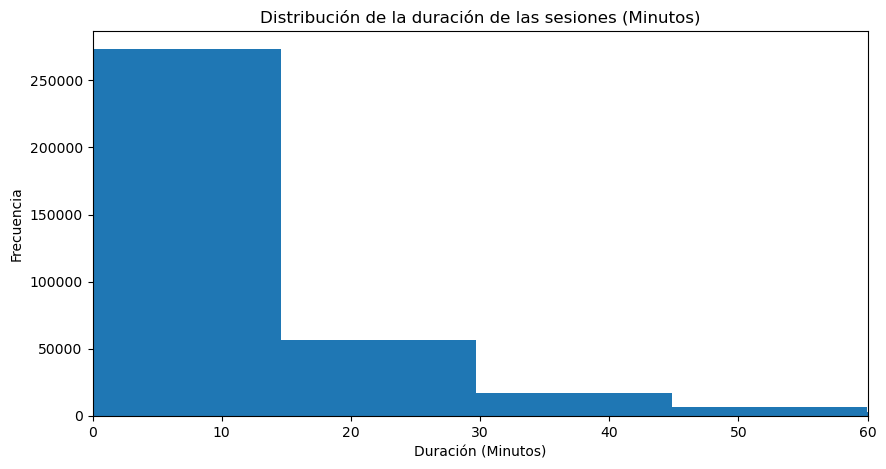

In [18]:
# Distribucion de la duracion de las sesiones
plt.figure(figsize=(10,5))
plt.hist(visitas["session_duration"], bins=50)
plt.title("Distribución de la duración de las sesiones (Minutos)")
plt.xlabel("Duración (Minutos)")
plt.xlim(0, 60)
plt.ylabel("Frecuencia")
plt.show()

Una vez calculada la duración de cada sesión, se observa que los usuarios permanecen en la plataforma aproximadamente 10 minutos en promedio. Sin embargo, este valor debe interpretarse con precaución, ya que puede verse afectado por la presencia de valores atípicos.

En el conjunto de datos pueden existir sesiones con duración extremadamente corta, incluso menores a un segundo, lo cual podría deberse a accesos accidentales, problemas de conectividad o cierres inmediatos de la página. Por otro lado, también se observan sesiones con duraciones significativamente superiores al promedio, como aquellas que alcanzan aproximadamente 28 minutos.

Estas variaciones pueden explicarse por diferencias en el comportamiento de los usuarios, su nivel de interés en la plataforma o la naturaleza del contenido consultado. En conjunto, estos valores atípicos influyen en el promedio general y deben considerarse al interpretar la duración media de las sesiones.

# 5.1.4 ¿CON QUÉ FRECUENCIA LOS USUARIOS REGRESAN?

In [19]:
# Calculo de la frecuencia de retorno de los usuarios en semanas
visitas_sorted = visitas.sort_values(by=["uid", "start_ts"])

# Multiplicamos el año por 52 y sumamos la semana de la ISO calendar para tener un conteo continuo
visitas_sorted["start_week"] = (visitas_sorted["start_ts"].dt.year * 52) + visitas_sorted["start_ts"].dt.isocalendar().week
visitas_sorted["end_week"] = (visitas_sorted["end_ts"].dt.year * 52) + visitas_sorted["end_ts"].dt.isocalendar().week

In [20]:
# Aplicamos el shift por grupo para que la visita anterior pertenezca al mismo usuario
visitas_sorted["pre_visit_week"] = visitas_sorted.groupby("uid")["start_week"].shift(1)
visitas_sorted["week_visits"] = (visitas_sorted["start_week"] - visitas_sorted["pre_visit_week"])
visitas_sorted["week_visits"].mean()

np.float64(4.0148211931632005)

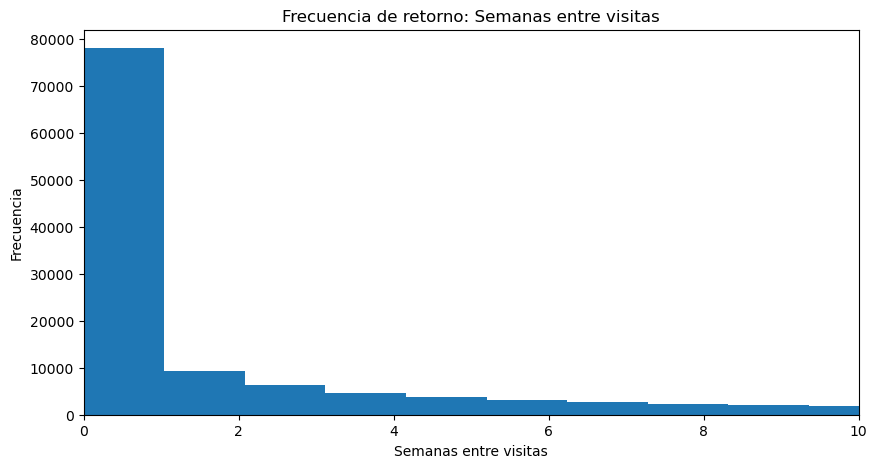

In [21]:
plt.figure(figsize=(10,5))
plt.hist(visitas_sorted["week_visits"], bins=50)
plt.title("Frecuencia de retorno: Semanas entre visitas")
plt.xlabel("Semanas entre visitas")
plt.xlim(0, 10)
plt.ylabel("Frecuencia")
plt.show()

El análisis de la frecuencia de retorno de los usuarios revela un patrón de comportamiento altamente recurrente y cíclico dentro de Showz. El histograma acotado demuestra que el mayor volumen de interacciones repetidas ocurre de forma inmediata dentro de la semana 0, lo que refleja que los usuarios en fase de exploración activa o decisión de compra ingresan múltiples veces en sus primeros siete días. Posteriormente, el leve repunte observado entre las semanas 4 y 5 se alinea perfectamente con el promedio general calculado de 4.01 semanas, confirmando la existencia de un segmento de clientes con un hábito de consumo estrictamente mensual, fuertemente vinculado a los ciclos de planificación de eventos y presupuestos personales. Dado que la probabilidad de retorno decrece de forma drástica a partir de la sexta semana, se concluye que la ventana crítica para la retención se concentra en el primer mes de actividad. Para el equipo de marketing, este hallazgo implica que las estrategias de fidelización deben ejecutarse de inmediato durante la primera semana, mientras que las campañas de reactivación y remarketing automatizado deben programarse con una periodicidad exacta de 28 días para capturar al usuario en su momento natural de retorno antes de que entre en una fase de inactividad prolongada.

# 5.2 METRICAS DE VENTAS

# 5.2.1 ¿CUÁNDO EMPIEZA LA GENTE A COMPRAR?

In [22]:
# Se extra la primera visita (registro) de cada usuario
first_visit = visitas.groupby("uid")["start_ts"].min().reset_index().rename(columns={"start_ts":"first_visit"})
first_visit.head()

,uid,first_visit
0,11863502262781,2018-03-01 17:27:00
1,49537067089222,2018-02-06 15:55:00
2,297729379853735,2017-06-07 18:47:00
3,313578113262317,2017-09-18 22:49:00
4,325320750514679,2017-09-30 14:29:00


In [23]:
# Se extra el prumer pedido de cada usuario
first_order = ordenes.groupby("uid")["buy_ts"].min().reset_index().rename(columns={"buy_ts":"first_order"})
first_order.head()

,uid,first_order
0,313578113262317,2018-01-03 21:51:00
1,1575281904278712,2017-06-03 10:13:00
2,2429014661409475,2017-10-11 18:33:00
3,2464366381792757,2018-01-28 15:54:00
4,2551852515556206,2017-11-24 10:14:00


In [24]:
# Unimos los dataframes nuevos para determinar el tiempo hasta la conversion
conversion = pd.merge(first_visit, first_order, on="uid")
conversion.head()

,uid,first_visit,first_order
0,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00
1,1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00
2,2429014661409475,2017-10-11 17:14:00,2017-10-11 18:33:00
3,2464366381792757,2018-01-27 20:10:00,2018-01-28 15:54:00
4,2551852515556206,2017-11-24 10:14:00,2017-11-24 10:14:00


In [25]:
# Se calcula el tiempo transcurrido para conversion en semanas de los usuarios 
conversion["conversion_weeks"] = (conversion["first_order"]-conversion["first_visit"]).dt.days/7
conversion

,uid,first_visit,first_order,conversion_weeks
0,313578113262317,2017-09-18 22:49:00,2018-01-03 21:51:00,15.142857
1,1575281904278712,2017-06-03 10:13:00,2017-06-03 10:13:00,0.000000
2,2429014661409475,2017-10-11 17:14:00,2017-10-11 18:33:00,0.000000
3,2464366381792757,2018-01-27 20:10:00,2018-01-28 15:54:00,0.000000
4,2551852515556206,2017-11-24 10:14:00,2017-11-24 10:14:00,0.000000
...,...,...,...,...
36518,18445147675727495770,2017-08-20 13:30:00,2017-11-24 09:03:00,13.571429
36519,18445407535914413204,2017-09-22 23:48:00,2017-09-22 23:55:00,0.000000
36520,18445601152732270159,2017-08-07 11:51:00,2018-03-26 22:54:00,33.000000
36521,18446156210226471712,2017-11-07 10:01:00,2018-02-18 19:34:00,14.714286


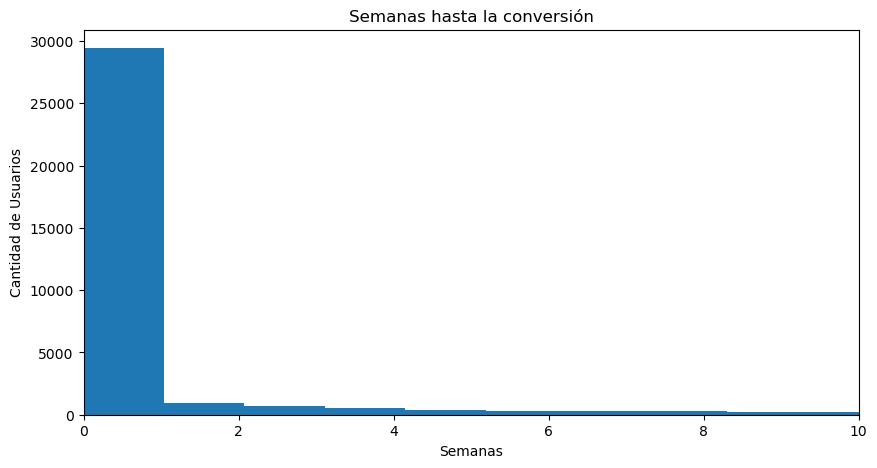

In [26]:
# Se genera un histograma para observar la conversion
plt.figure(figsize=(10,5))
plt.hist(conversion["conversion_weeks"], bins=50)
plt.title("Semanas hasta la conversión")
plt.xlabel("Semanas")
plt.xlim(0,10)
plt.ylabel("Cantidad de Usuarios")
plt.show()

El gráfico permite concluir de forma contundente que el proceso de conversión en Showz ocurre predominantemente de manera inmediata. La gran mayoría de los usuarios realiza su primera compra dentro de la semana 0, es decir, en el transcurso de los primeros siete días desde su interacción inicial con la plataforma. Aunque se registra un volumen menor de clientes que concreta su primer pedido durante la semana 1 (su segunda semana de contacto), la concentración masiva de los datos en el periodo inicial demuestra que el canal de adquisición es efectivo y que los usuarios ingresan al sitio con una intención de compra clara y de alta urgencia.

# 5.2.2 ¿CUÁNTOS PEDIDOS HACEN DURANTE UNA SEMANA? 

In [27]:
# Pedidos por semana
pedidos_semanales = ordenes.set_index("buy_ts").resample("W")["uid"].count().reset_index()
pedidos_semanales.sample(5)

,buy_ts,uid
49,2018-05-13,635
39,2018-03-04,1252
12,2017-08-27,480
29,2017-12-24,1184
50,2018-05-20,1004


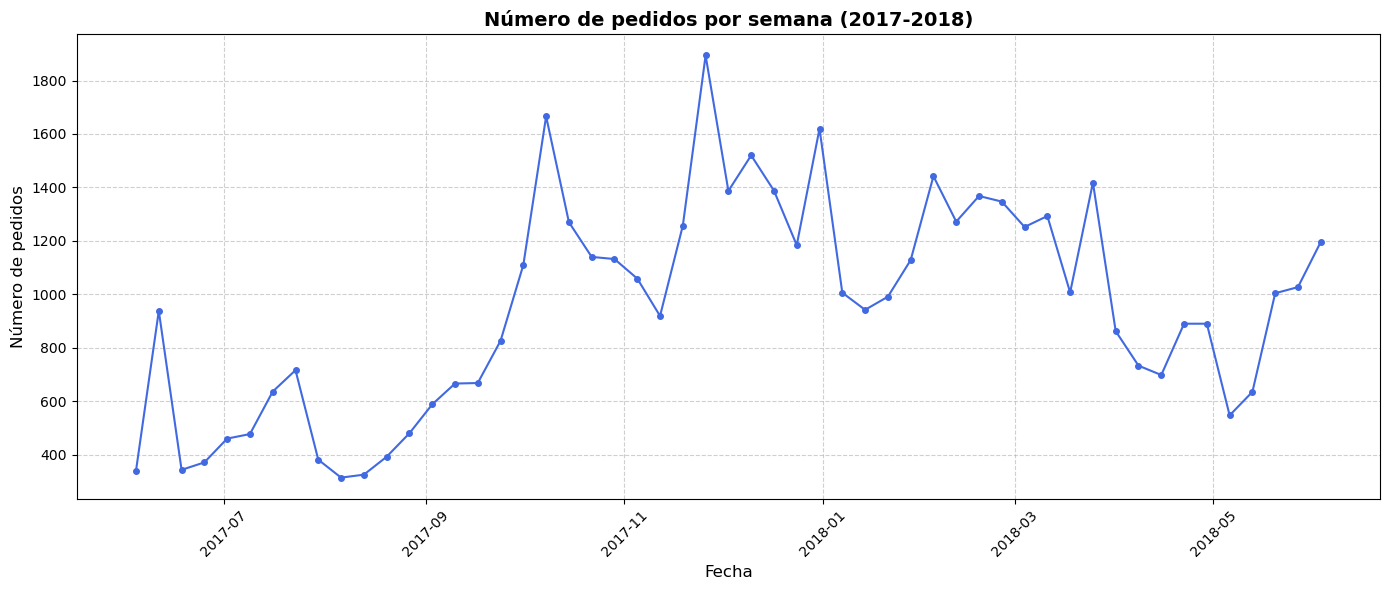

In [28]:
plt.figure(figsize=(14, 6))
plt.plot(pedidos_semanales["buy_ts"], pedidos_semanales["uid"], marker="o", color="royalblue", linewidth=1.5, markersize=4)
plt.title("Número de pedidos por semana (2017-2018)", fontsize=14, fontweight='bold')
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Número de pedidos", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

El análisis temporal de las transacciones muestra un comportamiento dinámico con fluctuaciones naturales, logrando consolidar un promedio cercano a los 900 pedidos semanales a lo largo del periodo analizado. Esta regularidad es un indicador sólido de una conversión madura y constante de visitantes a compradores.

Al evaluar la trayectoria del negocio, se identifican tres fases críticas:

- Periodo de Introducción: Durante las primeras semanas de 2017 se registran los niveles más bajos del histórico, con cifras inferiores a los 400 pedidos semanales. Este comportamiento es habitual en las fases iniciales de una plataforma digital, asociándose a la curva de adopción del servicio y al posicionamiento de la marca en el mercado.
- Estabilización y Madurez: Tras superar la etapa de arranque, la plataforma experimentó un crecimiento acelerado y entró en un ciclo de estabilidad. Aunque presenta un comportamiento oscilatorio (subes y bajas), las ventas lograron orbitar de forma consistente alrededor de la media estimada durante la mayor parte del año y medio siguiente.
- Estacionalidad de Cierre (2018): Hacia la recta final de 2018 se observa una contracción transitoria en el volumen de transacciones. No obstante, la gráfica muestra una rápida recuperación económica impulsada directamente por la temporada de vacaciones de fin de año, un fenómeno estacional característico en el sector de la venta de entradas a eventos.

# 5.2.3 ¿CUÁL ES EL TAMAÑO PROMEDIO DE COMPRA?

In [29]:
promedio = ordenes["revenue"].mean()
print(f"El valor promedio de las compras es de: ${promedio}")

El valor promedio de las compras es de: $4.999646930477041


In [30]:
ordenes["revenue"].describe()

count    50415.000000
mean         4.999647
std         21.818359
min          0.000000
25%          1.220000
50%          2.500000
75%          4.890000
max       2633.280000
Name: revenue, dtype: float64

El cálculo demuestra que el tamaño promedio de compra (ingreso percibido por cada transacción) es de $4.99 dólares. Este valor revela que el flujo principal de facturación de Showz proviene de transacciones de bajo costo unitario.

Si bien este comportamiento podría sugerir la adquisición de entradas económicas en volumen (compras grupales), es importante mantener un enfoque crítico: la base de datos actual no desglosa la cantidad de boletos emitidos por pedido. Por lo tanto, este promedio de ~$5 dólares también podría explicarse por la venta de accesos individuales a eventos de bajo costo, o bien, podría representar únicamente la tasa de comisión por servicio (service fee) que la plataforma retiene por cada transacción gestionada. Para confirmar cualquiera de estas hipótesis, sería necesario enriquecer el modelo con variables adicionales como el valor nominal unitario y el volumen de inventario por orden.

# 5.2.4 ¿CUÁNTO DINERO TRAEN? (CALCULO DE LTV)

In [31]:
# Se crea una columna con las ordenes semanales
ordenes["orden_semanal"] = ordenes["buy_ts"].dt.to_period('W').dt.to_timestamp()
# Se crea una columna con los costos semanales
costos["costo_semanal"]  = costos["dt"].dt.to_period('W').dt.to_timestamp()

In [32]:
# Se identifican las primeras ordenes y se crea un dataframe nuevo
first_orders = ordenes.groupby("uid").agg({"orden_semanal":min}).reset_index()
first_orders.columns = ["uid", "first_order_week"]

C:\Users\Usuario\AppData\Local\Temp\ipykernel_17500\3554134703.py:2: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  first_orders = ordenes.groupby("uid").agg({"orden_semanal":min}).reset_index()


In [33]:
cohort_sizes = (first_orders.groupby("first_order_week").agg({"uid":"nunique"}).reset_index())
cohort_sizes.columns = ["first_order_week", "n_buyers"]

C:\Users\Usuario\AppData\Local\Temp\ipykernel_17500\2481495051.py:32: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result.replace('', np.nan).astype(float),


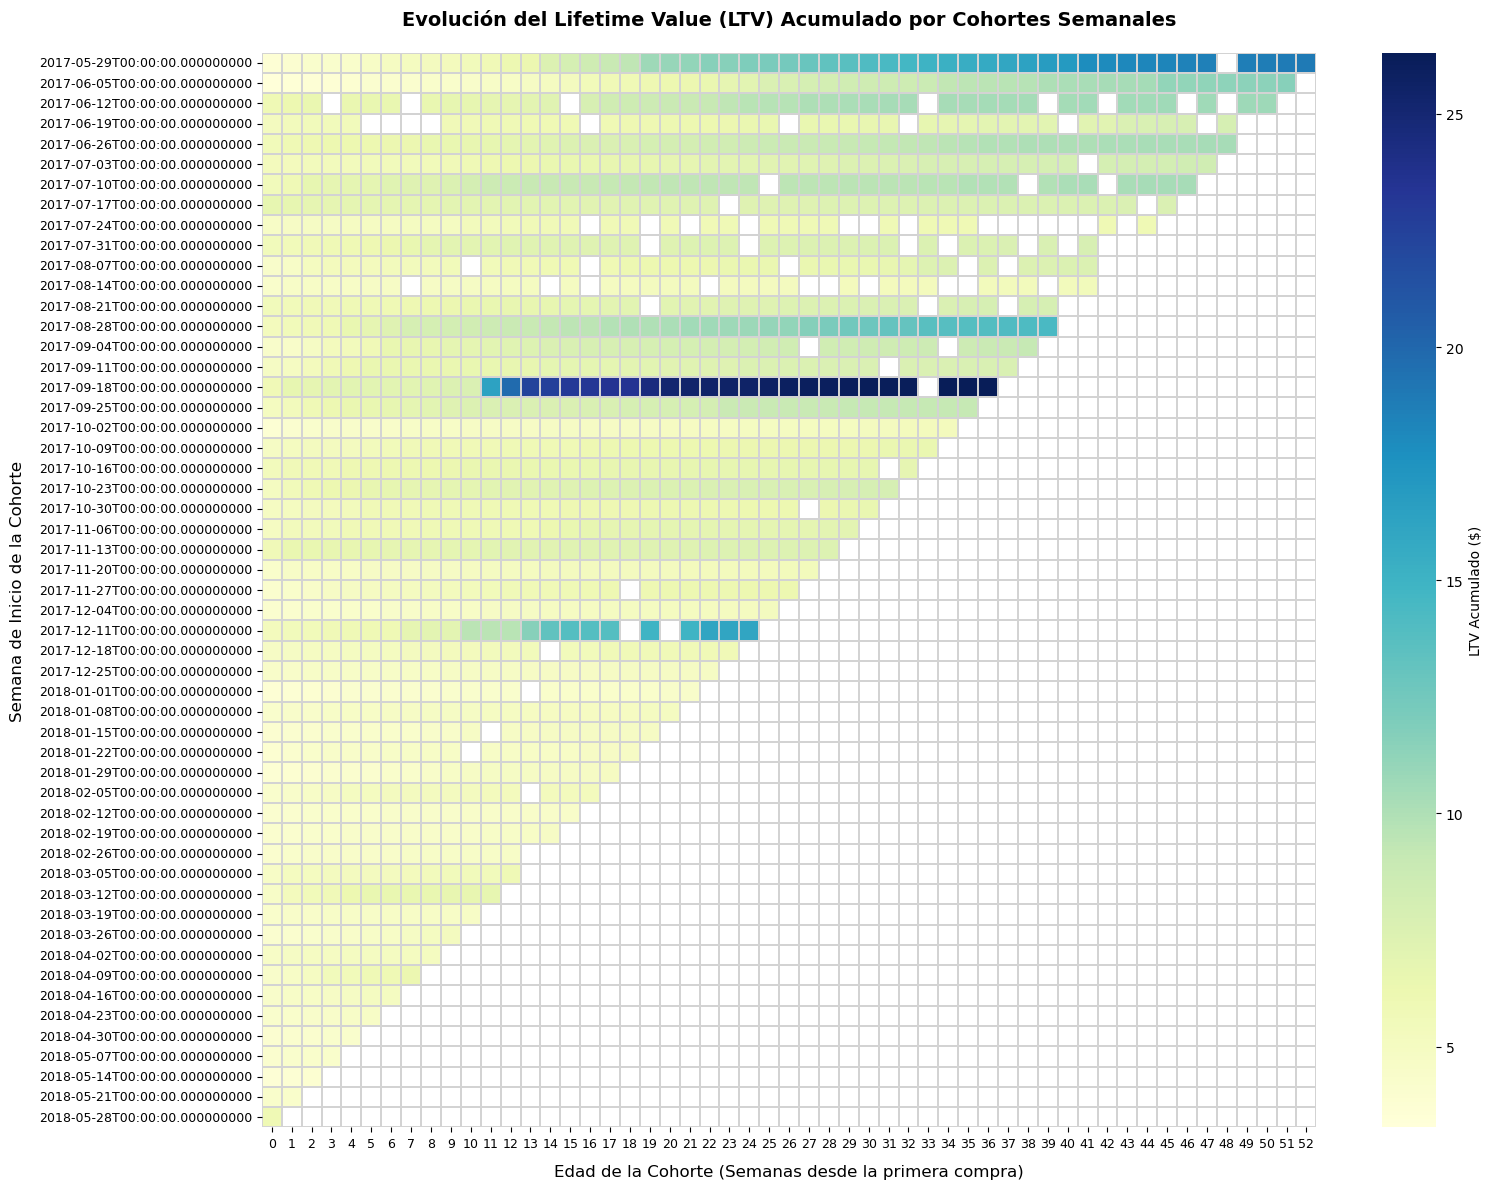

In [34]:
# Se agrega la semana del primer pedido al DataFrame con compras
ordenes1 = pd.merge(ordenes, first_orders, on="uid")
# Se agrupa los pedidos en cohortes
cohorts = ordenes1.groupby(["first_order_week", "orden_semanal"]).agg({"revenue":"sum"}).reset_index()
# Se fusiona las cohortes y cohort_sizes
report = pd.merge(cohort_sizes, cohorts, on="first_order_week")
# Se la edad de la cohorte en SEMANAS (Dividiendo por el delta de tiempo de 1 semana 'W')
report['age'] = (report["orden_semanal"] - report["first_order_week"]) / np.timedelta64(1, 'W')
report['age'] = report['age'].round().astype('int')
# Se calcula el LTV semanal (Ingreso directo entre el número de compradores)
report['ltv'] = report['revenue'] / report['n_buyers']
# Se calcula el LTV acumulado por cohorte para ver el ciclo de vida real
report['ltv_cum'] = report.groupby('first_order_week')['ltv'].cumsum()
# Se crea la tabla pivote final con el LTV Acumulado
result = report.pivot_table(
    index = "first_order_week",
    columns = "age",
    values = "ltv_cum",
    aggfunc = "mean"
).round(2) # Usamos 2 decimales para apreciar los centavos en los reingresos semanales

# Se limpia valores nulos para la presentación gráfica
result = result.fillna('')
result


plt.figure(figsize=(16, 12)) 

plt.title('Evolución del Lifetime Value (LTV) Acumulado por Cohortes Semanales', fontsize=14, fontweight='bold', pad=20)

sns.heatmap(
    result.replace('', np.nan).astype(float),
    annot=False,          # Falso para eliminar el amontonamiento de números
    cmap='YlGnBu',       # Paleta secuencial perfecta para ver el crecimiento
    linewidths=0.1,       # Líneas extremadamente delgadas para no saturar
    linecolor='lightgray',
    cbar_kws={'label': 'LTV Acumulado ($)'}
)

# Se formatea el eje X (Edad en semanas)
plt.xlabel('Edad de la Cohorte (Semanas desde la primera compra)', fontsize=12, labelpad=10)

# Se formatea el eje Y (Fechas de inicio)
plt.ylabel('Semana de Inicio de la Cohorte', fontsize=12, labelpad=10)

# Se rota y ajusta el tamaño de las fuentes de los ejes para máxima claridad
plt.xticks(rotation=0, fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

El mapa de calor permite evaluar de manera visual y cronológica cómo evoluciona el valor financiero de los clientes a lo largo de sus semanas de vida en la plataforma. A partir de la distribución de colores, se identifican las siguientes dinámicas clave del negocio:

- Comportamiento Base y Estabilidad del LTV: Al observar la columna de la Semana 0 (el extremo izquierdo), se evidencia una consistencia absoluta en color amarillo claro uniforme. Esto confirma nuestro hallazgo previo: el ticket inicial de los usuarios nuevos es sumamente estable, situándose en torno a los $4.99 dólares. En la gran mayoría de las cohortes, el crecimiento horizontal hacia la derecha es lento y gradual, manteniendo tonos amarillos y verdes claros, lo que indica que el reingreso orgánico semanal por usuario es marginal para la mayor parte de los segmentos.

- Anomalía Excepcional: La Cohorte del 18 de Septiembre de 2017 (2017-09-18): Esta es la campaña o hito más importante de todo el histórico de Showz. A partir de la semana 11 de vida de esta cohorte, el LTV sufre un incremento vertical drástico, tornándose en un azul marino intenso que llega a superar los $25.00 dólares por usuario.

- Interpretación comercial: Este comportamiento no es orgánico; representa un éxito atípico. Pudo deberse a una campaña de retención extremadamente agresiva, al lanzamiento de un beneficio exclusivo de alta fidelización, o a que este grupo específico adquirió entradas para un festival masivo de alta gama que se celebró de forma recurrente durante esas semanas. Es un caso de estudio obligatorio para que el equipo de marketing intente replicar su estrategia.

- Fines de Mayo/Junio 2017 (Primeras filas): Muestran un crecimiento sostenido a largo plazo, alcanzando tonos azules hacia las semanas 40-52. Esto refleja una excelente retención de los primeros usuarios de la base de datos, quienes maduraron con la plataforma y mantuvieron compras repetidas a lo largo de un año completo.

- Mediados de Diciembre 2017 (2017-12-11): Presenta un repunte acelerado (tonos turquesas) entre las semanas 10 y 24. Esto coincide temporalmente con la temporada de eventos del primer trimestre de 2018, demostrando que los usuarios adquiridos antes de las festividades decembrinas mantuvieron una alta actividad en los meses posteriores.

- La forma triangular del gráfico hacia la parte inferior es el comportamiento matemático correcto para un análisis de cohortes. Las cohortes de 2018 (filas inferiores) muestran menos columnas hacia la derecha simplemente porque son usuarios más recientes y el dataset finalizó antes de que pudiesen cumplir 52 semanas de historial.

# 5.3 MARKETING

# 5.3.1 ¿CUÁNTO DINERO SE GASTO?

In [35]:
# Calculo del costo total
costo_total = costos["costs"].sum()
print(f"El costo total generado por la empresa fue de: ${costo_total:.2f}")

El costo total generado por la empresa fue de: $329131.62


In [36]:
# Calculo de costos semanales y segun el canal
costos_semanales = costos.groupby(["costo_semanal", "source_id"]).sum("costs").reset_index()
costos_semanales.head()

,costo_semanal,source_id,costs
0,2017-05-29,1,228.98
1,2017-05-29,2,421.22
2,2017-05-29,3,1249.59
3,2017-05-29,4,357.31
4,2017-05-29,5,314.76


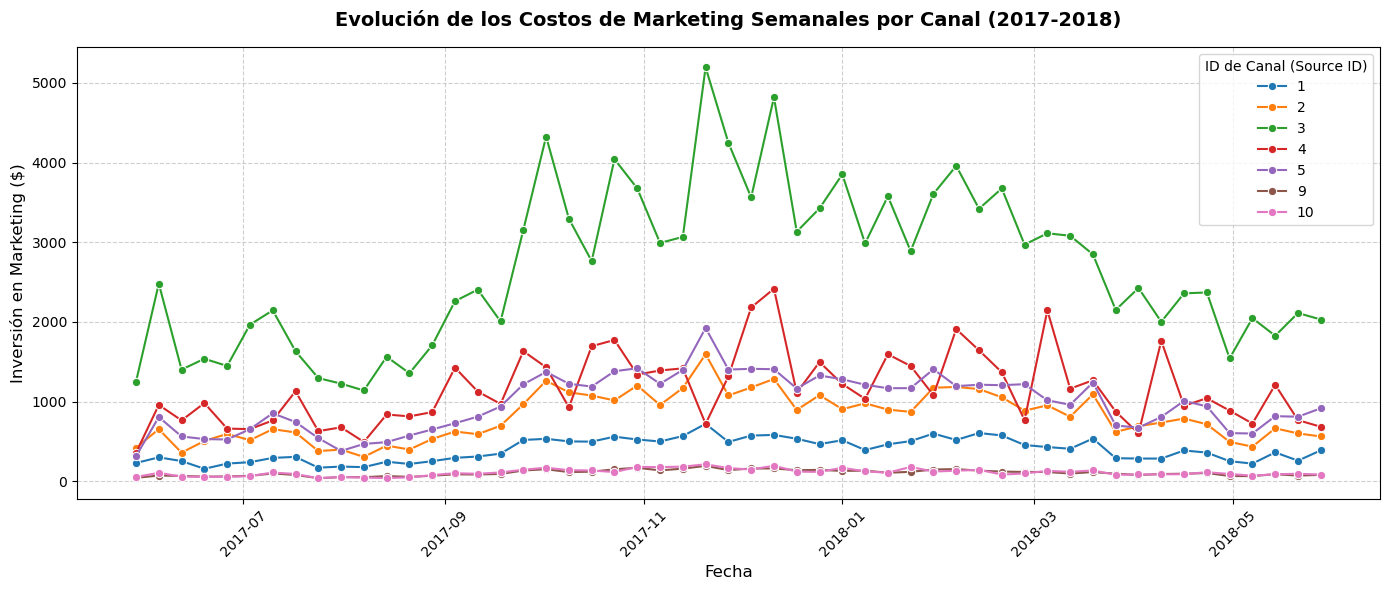

In [37]:
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=costos_semanales, 
    x="costo_semanal", 
    y="costs", 
    hue="source_id",    
    marker="o", 
    palette="tab10",    
    linewidth=1.5
)
plt.title("Evolución de los Costos de Marketing Semanales por Canal (2017-2018)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Inversión en Marketing ($)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="ID de Canal (Source ID)", loc="upper right") # Controla la leyenda de los colores
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Tras consolidar las métricas financieras, se determinó que Showz generó un costo total de marketing de $329,131.62 dólares a lo largo de los dos años analizados. Al desglosar este presupuesto bajo una perspectiva temporal semanal y por canales, se identifican las siguientes dinámicas de inversión:

1. Dominio del Canal 3: Este medio destaca como el principal receptor de recursos de la compañía. Su alta inversión suele responder a una estrategia deliberada para capturar el mayor volumen de interacciones con los usuarios, o bien, a que aloja las campañas publicitarias de mayor impacto y conversión para el negocio.

2. Comportamiento de Canales Secundarios: Los canales intermedios mantienen estructuras de costos sumamente similares y estables entre sí, compartiendo el esfuerzo de adquisición secundaria.

3. Zonas de Baja Inversión (Canales 1, 9 y 10): Estos medios registran los presupuestos más bajos del histórico. Ante esto, es imperativo realizar una auditoría interna bajo dos hipótesis comerciales:

- Alta eficiencia de conversión (Canales Orgánicos/Referidos): Si estos canales presentan un costo bajo pero una conversión alta, representan una ventaja competitiva que no requiere de inyecciones masivas de capital.

- Naturaleza del Medio (Tradicional o Residual): Podría tratarse de canales con limitaciones de escalabilidad o medios tradicionales cuyos costos fijos son mínimos, justificando su baja participación en el presupuesto digital.

# 5.3.2 ¿CUÁL FUE EL COSTO DE ADQUISICIÓN DE CLIENTES DE CADA UNA DE LAS FUENTES?

In [38]:
# Calculo total de costo por fuente
costo_fuente = costos.groupby("source_id")["costs"].sum()
costo_fuente.head(10)

source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64

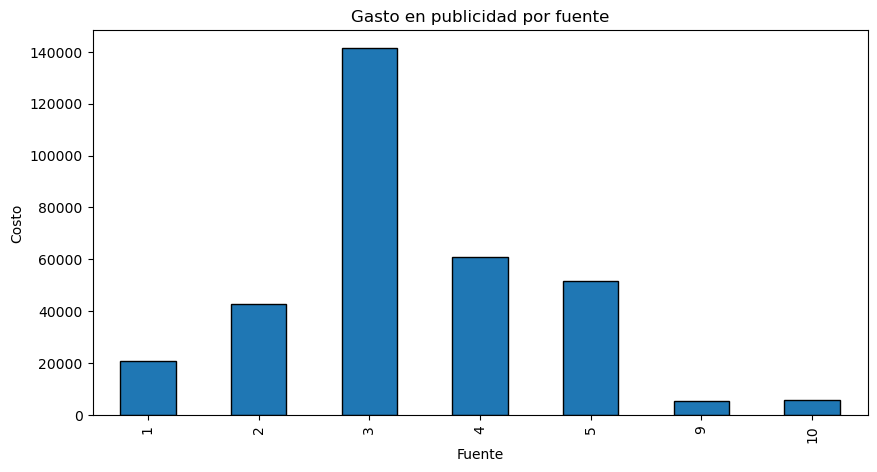

In [39]:
# Grafico del total de gastos por fuente
plt.figure(figsize=(10,5))
costo_fuente.plot(kind="bar", edgecolor="black")
plt.title("Gasto en publicidad por fuente")
plt.xlabel("Fuente")
plt.ylabel("Costo")
plt.show()

La evaluación cuantitativa y la representación gráfica de la estructura de gastos reafirman el rol crítico del Canal 3 como el motor principal de inversión de Showz, concentrando el mayor flujo de capital destinado a garantizar la visibilidad de la plataforma y la captación masiva de usuarios.

Por otro lado, los Canales 2, 4 y 5 exhiben un comportamiento secundario homogéneo; si bien reciben una inyección constante de recursos para mantener la competitividad, su participación presupuestaria es moderada en comparación con el canal líder. Finalmente, los Canales 1, 9 y 10 se consolidan como los más rezagados en términos de costos. Esta condición los convierte en un objeto de estudio prioritario para las siguientes fases del análisis, donde se evaluará si su bajo gasto se traduce en una excelente eficiencia operativa (alto volumen de conversión con bajo presupuesto) o si requieren una reestructuración estratégica por falta de alcance comercial.

# 5.3.3 ¿CUÁN RENTABLES ERAN LAS INVERSIONES? (ROMI)

In [40]:
# Fuente de adquisicion de cada usuario en su primer registro
user_source = visitas.sort_values(by="start_ts").groupby("uid").first().reset_index()[["uid", "source_id"]]
user_source.head()

,uid,source_id
0,11863502262781,3
1,49537067089222,2
2,297729379853735,3
3,313578113262317,2
4,325320750514679,5


In [41]:
# Se une la informacion de conversoin con la fuente
conversio_source = pd.merge(conversion, user_source, on="uid", how="left")

In [42]:
# Numero de clientes adquiridos por fuente
costumers_by_source = conversio_source.groupby("source_id")["uid"].nunique()
costumers_by_source.head(10)

source_id
1      2899
2      3506
3     10473
4     10296
5      6931
7         1
9      1088
10     1329
Name: uid, dtype: int64

In [43]:
# Calculo de costo de adquisicion de clientes (CAC)
# Se calcula el CAC: Gasto de la fuente / numero de clientes adquieridos
cac = costo_fuente / costumers_by_source
cac.head(10)

source_id
1      7.186364
2     12.209367
3     13.493901
4      5.931779
5      7.467479
7           NaN
9      5.071222
10     4.381106
dtype: float64

# CALCULO DE ROMI (RETURN ON MARKETING INVESTMENT)

In [44]:
# Se asocia las ordenes con la fuente de adquisicion 
order_source = pd.merge(ordenes, user_source, on="uid", how="left")
order_source.head()

,buy_ts,revenue,uid,orden_semanal,source_id
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-05-29,1
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-05-29,2
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-05-29,2
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-05-29,2
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-05-29,3


In [45]:
# Se calcula el ingreso por fuente
revenue_source = order_source.groupby("source_id")["revenue"].sum()
revenue_source.head()

source_id
1    31090.55
2    46923.61
3    54511.24
4    56696.83
5    52624.02
Name: revenue, dtype: float64

In [46]:
# Se calculo del ROMI 
romi = (revenue_source - costo_fuente) / costo_fuente
romi.head(10)

source_id
1     0.492351
2     0.096191
3    -0.614275
4    -0.071664
5     0.016750
7          NaN
9     0.043844
10   -0.235665
dtype: float64

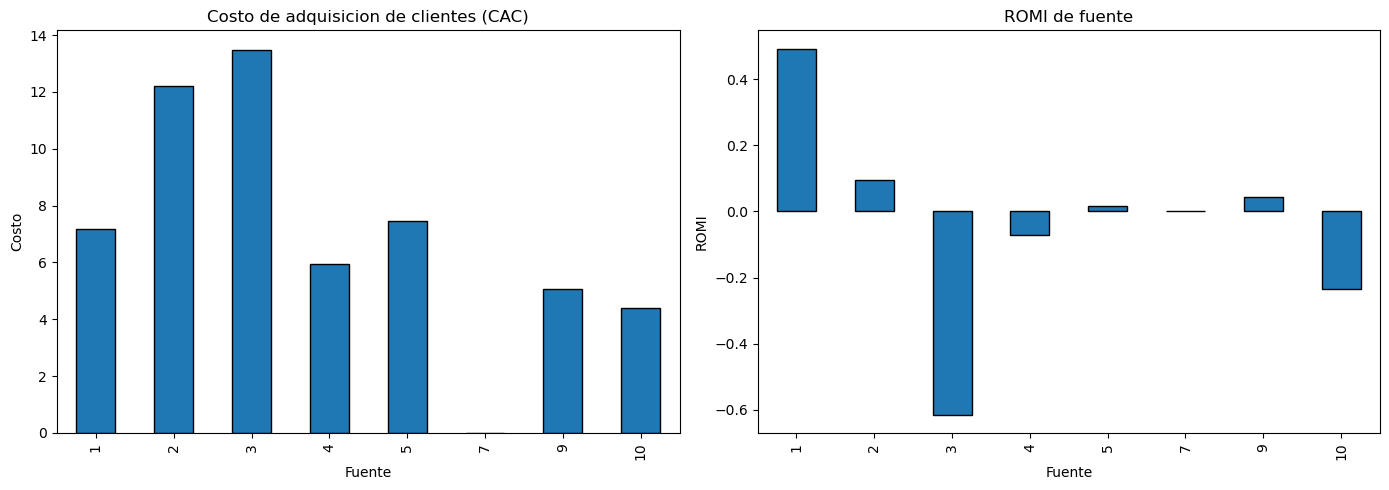

In [47]:
# Se grafica del CAC y ROMI
fig, ax= plt.subplots(1,2, figsize=(14, 5))

cac.plot(kind="bar", ax=ax[0], edgecolor="black")
ax[0].set_title("Costo de adquisicion de clientes (CAC)")
ax[0].set_xlabel("Fuente")
ax[0].set_ylabel("Costo")

romi.plot(kind="bar", ax=ax[1], edgecolor="black")
ax[1].set_title("ROMI de fuente")
ax[1].set_xlabel("Fuente")
ax[1].set_ylabel("ROMI")

plt.tight_layout()
plt.show()

El cruce de variables entre el volumen de usuarios atraídos, el costo de adquisición (CAC) y el retorno de la inversión en marketing (ROMI) permite validar hipótesis críticas sobre la eficiencia de cada canal de difusión:

- El Canal 3 (Alto volumen, baja eficiencia): Se confirma como el canal que mayor volumen de consumidores atrae a la plataforma (10,473 usuarios), pero a su vez registra el CAC más elevado. Esta falta de eficiencia se refleja directamente en el ROMI, demostrando que actualmente este canal genera más costos que beneficios económicos (operando con pérdidas). La estrategia de adquisición masiva en este medio debe ser reestructurada de inmediato.

- El Canal 1 (Confirmación de hipótesis de eficiencia): Como se sospechaba en el análisis de costos, resultó ser el canal más eficiente. Aunque no posee el alcance masivo del Canal 3, su bajísimo CAC garantiza que cada usuario adquirido genere beneficios netos, consolidando un ROMI altamente positivo.

Canales Críticos Bajo la Lupa:

- Canal 2 (Rendimiento limítrofe): Es el segundo canal más costoso del histórico. Su volumen de captación (3,506 usuarios) está sumamente lejos del líder, y su retorno apenas logra superar el umbral de equilibrio (punto de equilibrio o break-even). Al no presentar pérdidas pero ofrecer un rendimiento tan ajustado, requiere un replanteamiento estratégico para optimizar sus conversiones.

- Canal 4 (El mayor potencial de optimización): Este canal representa una oportunidad de oro. Logró atraer un volumen masivo de 10,296 usuarios (prácticamente igualando al Canal 3) pero con una inversión significativamente menor. Aunque su ROMI actual se encuentra en terreno ligeramente negativo, la pérdida es mínima. Su alta capacidad de tracción sugiere que, mediante un ajuste fino en la retención o un leve incremento en el ticket promedio, puede transformarse rápidamente en uno de los canales más rentables para la compañía.

# CONCLUSIONES GENERALES

Con base en el análisis integral de adquisición, costos y retorno de inversión, se propone una reestructuración del presupuesto de marketing enfocada en maximizar la eficiencia operativa y extender el ciclo de vida del cliente:

1. Reasignación Presupuestaria de Alto Impacto (Canal 3 al Canal 4): Se recomienda disminuir de forma inmediata la inversión en el Canal 3. Al ser un medio ineficiente que genera pérdidas operativas, parte de su capital remanente debe transferirse al Canal 4. Este último ha demostrado un potencial masivo de tracción (atrayendo más de 10,200 usuarios) con una inversión menor; este flujo de capital adicional le permitirá optimizar sus conversiones y cruzar rápidamente el umbral hacia la rentabilidad neta.

2. Reestructuración de Campañas en el Canal 2: Al encontrarse en un punto de equilibrio muy ajustado (break-even), este canal no debe descartarse aún, sino optimizarse. Se requiere una auditoría técnica en sus campañas activas para identificar cuellos de botella y mejorar la tasa de conversión, logrando que su alto costo se traduzca en una rentabilidad real y no solo en la recuperación de lo invertido.

3. Auditoría de Canales Rezagados (Filosofía de Eficiencia o Cierre):

Canales Saludables (como el Canal 1): Establecer un protocolo de monitoreo continuo para asegurar que mantengan sus excelentes márgenes de ganancia con su estructura actual de costos.

Canales en Pérdida Crítica (Canal 10): Se recomienda descartar de forma definitiva el Canal 10. A pesar de ser el medio con menor costo nominal, su volumen de captación es residual, lo que matemáticamente imposibilita mitigar sus gastos fijos de operación, traduciéndose en pérdidas netas insostenibles para la organización.

# Optimización del Ciclo de Vida y Retención (Customer Journey)

Aunque el flujo de ingresos semanales se ha mantenido en niveles óptimos y saludables (~900 pedidos por semana), el verdadero crecimiento de Showz no dependerá únicamente de captar nuevos clientes de manera eficiente. Las mejoras propuestas en los canales de adquisición deben sincronizarse con estrategias sólidas de retención y fidelización (como programas de lealtad o automatización de emails posventa). Al alargar la permanencia del cliente dentro del Customer Journey, incrementaremos el valor del tiempo de vida (Lifetime Value), asegurando la sostenibilidad financiera del negocio a largo plazo.